In [77]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [79]:
day_df = pd.read_csv("/content/drive/MyDrive/day.csv")
hour_df = pd.read_csv("/content/drive/MyDrive/hour.csv")

In [80]:
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
day_df['year'] = day_df['dteday'].dt.year
day_df['month'] = day_df['dteday'].dt.month
day_df['day'] = day_df['dteday'].dt.day
day_df['is_weekend'] = day_df['weekday'].apply(lambda x: 1 if x in [5, 6] else 0)
day_df['weather_index'] = (day_df['temp'] + day_df['hum'] + day_df['windspeed'])

In [81]:
leakage_cols = ['instant', 'dteday', 'casual', 'registered']
day_df = day_df.drop(leakage_cols, axis=1)
day_df = pd.get_dummies(day_df, columns=['season', 'weathersit', 'weekday'], drop_first=True)

In [82]:
X_day = day_df.drop('cnt', axis=1)
y_day = day_df['cnt']

print(f"✓ Day Dataset Shape: {day_df.shape}")
print(f"✓ Features: {X_day.shape[1]} columns")
print(f"✓ Target: {y_day.shape[0]} samples")

✓ Day Dataset Shape: (731, 25)
✓ Features: 24 columns
✓ Target: 731 samples


In [83]:
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
hour_df['year'] = hour_df['dteday'].dt.year
hour_df['month'] = hour_df['dteday'].dt.month
hour_df['is_weekend'] = hour_df['weekday'].apply(lambda x: 1 if x in [5, 6] else 0)
hour_df['is_peak_hour'] = hour_df['hr'].apply(lambda x: 1 if x in [7, 8, 17, 18] else 0)
hour_df['weather_index'] = hour_df['temp'] + hour_df['hum'] + hour_df['windspeed']

In [84]:
leakage_cols = ['instant', 'dteday', 'casual', 'registered']
hour_df = hour_df.drop(leakage_cols, axis=1)
hour_df = pd.get_dummies(hour_df, columns=['season', 'weathersit', 'weekday'], drop_first=True)

In [85]:
X_hour = hour_df.drop('cnt', axis=1)
y_hour = hour_df['cnt']

print(f"✓ Hour Dataset Shape: {hour_df.shape}")
print(f"✓ Features: {X_hour.shape[1]} columns")
print(f"✓ Target: {y_hour.shape[0]} samples")

✓ Hour Dataset Shape: (17379, 27)
✓ Features: 26 columns
✓ Target: 17379 samples


In [86]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def train_and_evaluate(model_name, model, X_train, X_test, y_train, y_test, scale=False):
    """
    Trains a model and returns performance metrics
    """

    # Scaling if required
    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    results = {
        "Model": model_name,
        "Train_R2": r2_score(y_train, y_train_pred),
        "Test_R2": r2_score(y_test, y_test_pred),
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "Test_MAE": mean_absolute_error(y_test, y_test_pred)
    }

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")
    results["CV_R2_Mean"] = cv_scores.mean()
    results["CV_R2_Std"] = cv_scores.std()
    results["Overfit_Gap"] = results["Train_R2"] - results["Test_R2"]

    return results, model, y_test_pred


In [87]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

def get_models():
    return {
        "Ridge Regression": {
            "model": Ridge(alpha=10),
            "scale": True
        },
        "SVR": {
            "model": SVR(kernel="rbf", C=100),
            "scale": True
        },
        "Gradient Boosting": {
            "model": GradientBoostingRegressor(
                n_estimators=150,
                max_depth=5,
                learning_rate=0.1,
                random_state=42
            ),
            "scale": False
        },
        "XGBoost": {
            "model": XGBRegressor(
                n_estimators=200,
                max_depth=7,
                learning_rate=0.1,
                subsample=0.8,
                random_state=42
            ),
            "scale": False
        },
        "LightGBM": {
            "model": LGBMRegressor(
                n_estimators=200,
                learning_rate=0.1,
                num_leaves=31,
                random_state=42,
                verbose=-1
            ),
            "scale": False
        }
    }


In [88]:
def plot_model_comparison(results_df, title):
    plt.figure(figsize=(12,6))
    sns.barplot(x="Model", y="Test_R2", data=results_df, palette="viridis")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.ylim(0,1)
    plt.grid(axis="y", alpha=0.3)
    plt.show()


In [89]:
def plot_predictions(y_test, y_pred, model_name, dataset_name):
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             "r--")
    plt.xlabel("Actual Rentals")
    plt.ylabel("Predicted Rentals")
    plt.title(f"{model_name} – {dataset_name}")
    plt.grid(alpha=0.3)
    plt.show()


In [90]:
def plot_feature_importance(model, feature_names, title):
    if not hasattr(model, "feature_importances_"):
        return

    imp = pd.Series(model.feature_importances_, index=feature_names)
    imp.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8,6))
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.grid(axis="x", alpha=0.3)
    plt.show()


In [91]:
def run_pipeline(X, y, dataset_name):
    # Ensure 'dteday' and 'instant' are dropped if they somehow persist in X
    cols_to_drop_if_present = ['dteday', 'instant']
    X_processed = X.drop(columns=[col for col in cols_to_drop_if_present if col in X.columns], errors='ignore')

    X_train, X_test, y_train, y_test = train_test_split(
        X_processed, y, test_size=0.2, random_state=42
    )

    models = get_models()
    results = []
    trained_models = {}

    for name, cfg in models.items():
        res, model, y_pred = train_and_evaluate(
            name, cfg["model"],
            X_train, X_test,
            y_train, y_test,
            scale=cfg["scale"]
        )

        results.append(res)
        trained_models[name] = (model, y_pred)

    results_df = pd.DataFrame(results).sort_values("Test_R2", ascending=False)

    print(f"\n📊 Results – {dataset_name.upper()}")
    display(results_df)

    # Plot comparison
    plot_model_comparison(results_df, f"{dataset_name.upper()} Dataset – Model Comparison")

    # Best model visuals
    best_model_name = results_df.iloc[0]["Model"]
    best_model, best_pred = trained_models[best_model_name]

    plot_predictions(y_test, best_pred, best_model_name, dataset_name)
    # Check if the best_model has feature_importances_ or coef_ before plotting
    if hasattr(best_model, 'feature_importances_') or hasattr(best_model, 'coef_'):
        plot_feature_importance(best_model, X_processed.columns, # Use X_processed.columns here
                                f"{best_model_name} – Feature Importance ({dataset_name})")

    return results_df


📊 Results – DAY


,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Test_MAE,CV_R2_Mean,CV_R2_Std,Overfit_Gap
2,Gradient Boosting,0.997861,0.910047,88.556756,600.584920,418.157155,0.851813,0.042815,0.087814
3,XGBoost,0.999977,0.901617,9.170816,628.096156,428.736237,0.852544,0.033703,0.098360
4,LightGBM,0.995653,0.887459,126.234057,671.771058,435.471550,0.864254,0.043244,0.108194
0,Ridge Regression,0.822563,0.839305,806.492363,802.726040,601.023149,0.799420,0.068039,-0.016741
1,SVR,0.718449,0.690161,1015.914149,1114.638474,889.100692,0.625646,0.027491,0.028288


/tmp/ipython-input-4144749053.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Test_R2", data=results_df, palette="viridis")


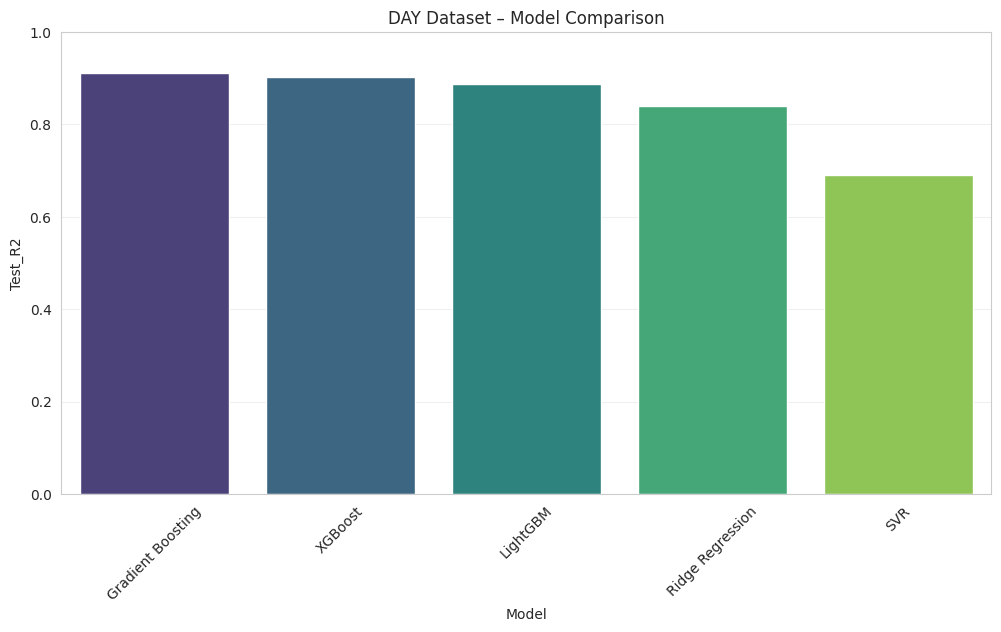

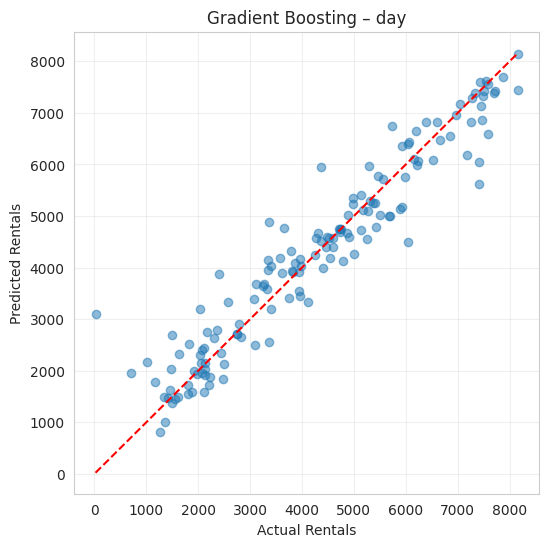

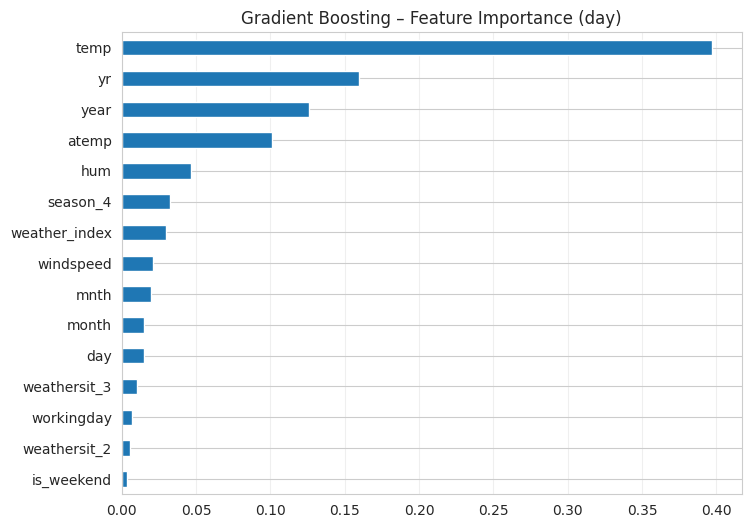


📊 Results – HOUR


,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Test_MAE,CV_R2_Mean,CV_R2_Std,Overfit_Gap
3,XGBoost,0.986098,0.955238,21.484296,37.648662,23.081196,0.952170,0.002780,0.030860
4,LightGBM,0.970088,0.952421,31.513985,38.815177,24.027779,0.949184,0.003005,0.017667
2,Gradient Boosting,0.957425,0.944288,37.597553,42.001673,26.894273,0.941263,0.003188,0.013137
1,SVR,0.843143,0.834714,72.166226,72.345335,51.672391,0.821472,0.011578,0.008429
0,Ridge Regression,0.570233,0.568313,119.453341,116.916813,88.938195,0.568468,0.010703,0.001920


/tmp/ipython-input-4144749053.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Model", y="Test_R2", data=results_df, palette="viridis")


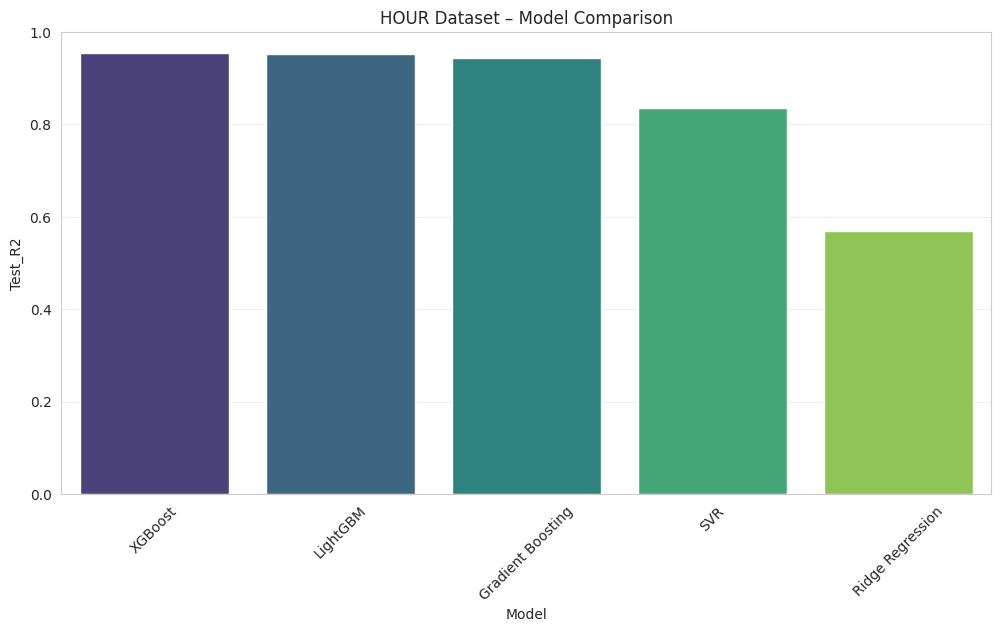

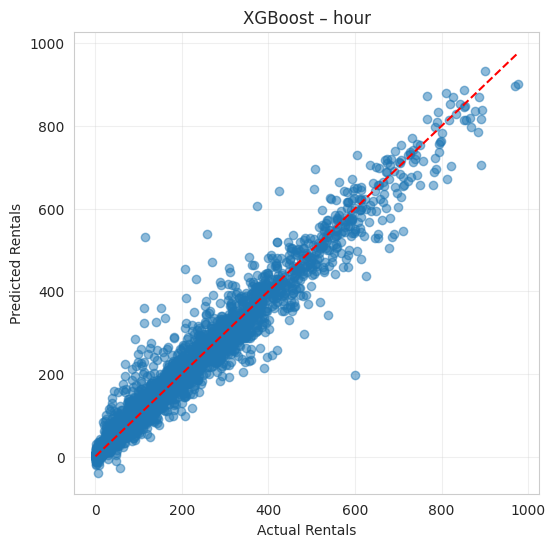

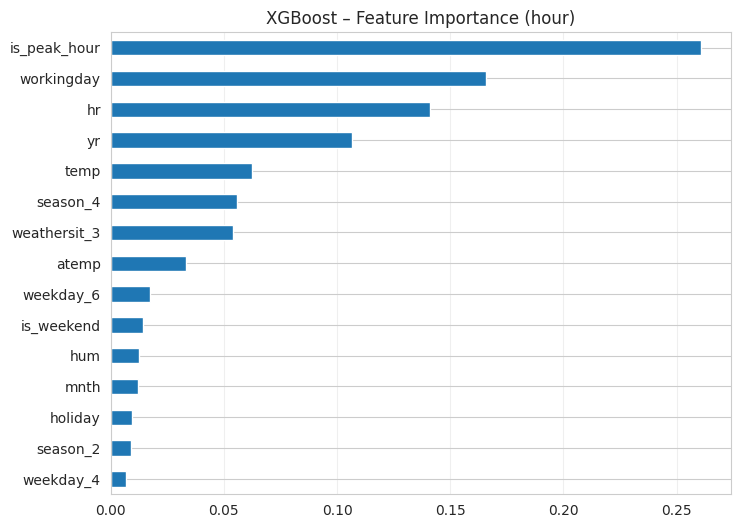

In [76]:
# DAY DATASET
day_results = run_pipeline(X_day, y_day, "day")

# HOUR DATASET
hour_results = run_pipeline(X_hour, y_hour, "hour")